In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [2]:

X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.0)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of training features (X_train): {X_train.shape}")
print(f"Shape of training labels (y_train): {y_train.shape}")
print(f"Shape of testing features (X_test): {X_test.shape}")
print(f"Shape of testing labels (y_test): {y_test.shape}")

Shape of training features (X_train): (80, 2)
Shape of training labels (y_train): (80,)
Shape of testing features (X_test): (20, 2)
Shape of testing labels (y_test): (20,)


In [3]:

svc_model = svm.SVC(kernel='linear', C=1.0)


svc_model.fit(X_train, y_train)

print("SVM model trained successfully!")
print(f"Number of support vectors for each class: {svc_model.n_support_}")

SVM model trained successfully!
Number of support vectors for each class: [1 2]


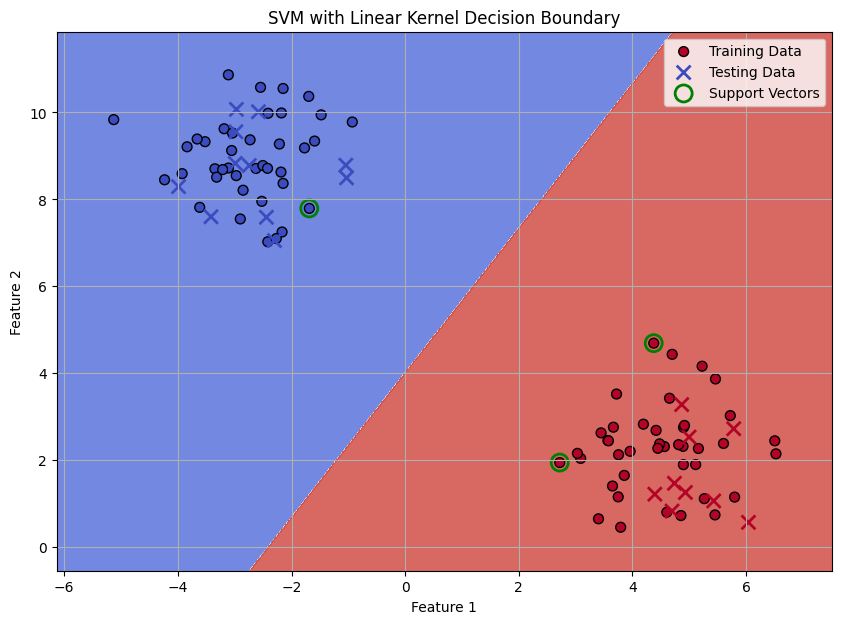

In [4]:

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))


Z = svc_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)


plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=50, edgecolors='k', label='Training Data')


plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, marker='x', s=100, linewidths=2, label='Testing Data')

plt.scatter(svc_model.support_vectors_[:, 0], svc_model.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='green', linewidths=2, label='Support Vectors')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM with Linear Kernel Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()